In [10]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("placement.csv")

In [12]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [14]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df = df.iloc[: ,1::]

In [20]:
df

,cgpa,iq,placement
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
5,7.1,48.0,1
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [21]:
import matplotlib.pyplot as plt

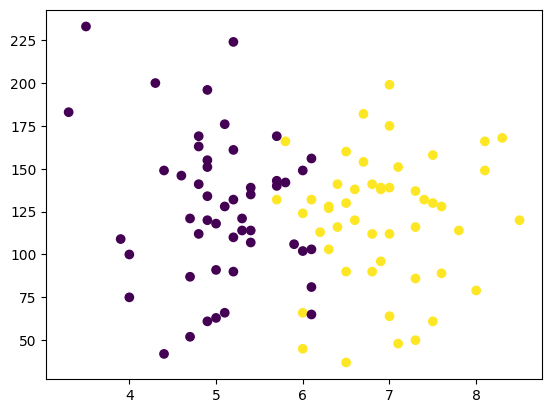

In [23]:
plt.scatter(df["cgpa"] , df["iq"] , c=df["placement"])

In [31]:
x = df.iloc[: , 0:2]
y = df.iloc[: , -1]

In [32]:
x

,cgpa,iq
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
5,7.1,48.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [33]:
y

,placement
1,0
2,0
3,1
4,0
5,1
...,...
95,0
96,0
97,1
98,1


In [35]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.1)

In [36]:
x_train

,cgpa,iq
4,5.8,142.0
79,6.5,90.0
93,6.8,112.0
16,5.2,224.0
71,6.1,132.0
...,...,...
17,3.3,183.0
2,5.3,121.0
86,5.1,128.0
58,8.0,79.0


In [37]:
y_train

,placement
4,0
79,1
93,1
16,0
71,1
...,...
17,0
2,0
86,0
58,1


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [39]:
x_train = scaler.fit_transform(x_train)

In [40]:
x_train

array([[-1.97971633e-01,  4.37684141e-01],
       [ 4.09596481e-01, -8.33880331e-01],
       [ 6.69982815e-01, -2.95910747e-01],
       [-7.18744301e-01,  2.44284350e+00],
       [ 6.24147019e-02,  1.93152512e-01],
       [-2.19426686e+00,  2.66292197e+00],
       [ 1.10396004e+00,  3.15418326e-01],
       [-8.05539746e-01,  1.26909168e+00],
       [-8.92335191e-01, -1.49191769e-01],
       [-7.18744301e-01,  1.93152512e-01],
       [-2.84767077e-01,  4.62137304e-01],
       [ 6.69982815e-01, -8.33880331e-01],
       [-1.11176188e-01, -4.42629724e-01],
       [-9.79130636e-01,  6.57762607e-01],
       [ 7.56778260e-01, -6.87161354e-01],
       [-1.49990330e+00,  1.85596759e+00],
       [-1.97971633e-01,  1.02456005e+00],
       [-1.06592608e+00,  9.51200562e-01],
       [-7.18744301e-01, -8.33880331e-01],
       [ 4.96391926e-01,  3.39871489e-01],
       [-2.84767077e-01,  1.09791954e+00],
       [ 4.09596481e-01,  8.77841074e-01],
       [-2.43807429e-02,  6.08856281e-01],
       [ 9.

In [45]:
x_test = scaler.fit_transform(x_test)

In [46]:
x_test

array([[-0.4033434 , -0.30195223],
       [-0.61562939, -1.87881385],
       [ 1.40108758,  0.6374547 ],
       [-0.72177239,  1.2078089 ],
       [ 0.76422959, -0.53680396],
       [-0.82791539, -0.23485173],
       [ 1.50723058,  1.87881385],
       [ 0.76422959,  0.26840198],
       [-0.1910574 , -0.40260297],
       [-1.67705938, -0.6374547 ]])

In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
clf = LogisticRegression()

In [56]:
clf.fit(x_train , y_train)

LogisticRegression()

In [57]:
y_pred = clf.predict(x_test)

In [58]:
y_pred

array([0, 0, 1, 0, 1, 0, 1, 1, 0, 0])

In [59]:
y_test

,placement
92,0
7,0
11,1
76,0
98,1
59,0
52,1
70,1
81,0
18,0


In [60]:
from sklearn.metrics import accuracy_score

In [61]:
accuracy_score(y_pred , y_test)

1.0

In [62]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

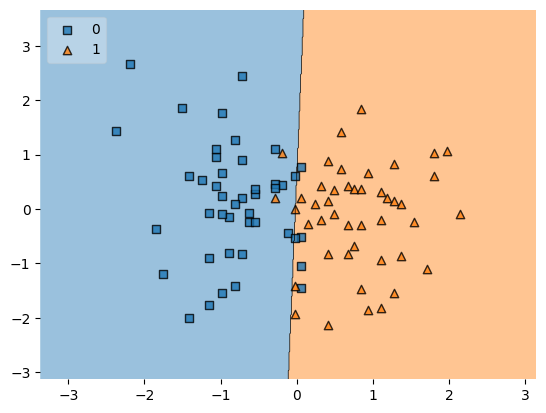

In [64]:
plot_decision_regions(x_train , y_train.values , clf=clf , legend=2)

In [65]:
import pickle

In [67]:
pickle.dump(clf,open("model.pkl", "wb"))